### Mashiur Rahman

# Part 1 — Load and Understand the Data

The stock information dataset describes securities and their exchanges, sectors, and industries. The price dataset contains daily trading records. Both datasets use `ticker` to identify a security.

### Import Required Library and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

### Stock Information

In [2]:
print("STOCK INFORMATION — first five rows")
display(stocks.head())

STOCK INFORMATION — first five rows


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


### Price sample

In [3]:
print("FULL PRICE DATASET — first five rows")
display(prices.head())

FULL PRICE DATASET — first five rows


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


In [4]:
print("Stock information shape:", stocks.shape)
print("Full price data shape:", prices.shape)

print("\nSTOCK INFORMATION")
stocks.info()

print("\nFULL PRICE DATA")
prices.info()

Stock information shape: (6460, 5)
Full price data shape: (20973889, 8)

STOCK INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ticker    6460 non-null   str  
 1   exchange  6460 non-null   str  
 2   name      6460 non-null   str  
 3   sector    5020 non-null   str  
 4   industry  5020 non-null   str  
dtypes: str(5)
memory usage: 252.5 KB

FULL PRICE DATA
<class 'pandas.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     str    
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       str    
dtypes: float64(5), int64(1), str(2)
memory usage: 1.3 GB


## Part 1 Answers

1. **What does each dataset represent?**  
   `historical_stocks.csv` contains information about securities, including their ticker, exchange, name, sector, and industry. `historical_stock_prices.csv` contains daily prices and trading volume.

2. **What is the purpose of `ticker`?**  
   A ticker identifies a security, such as `AHH`. It allows us to find that security's price records.

3. **How are the datasets related?**  
   The datasets can be connected using `ticker`. One security in the stock information dataset can have many daily records in the price dataset.

4. **How many rows and columns are there?**  
   The stock information dataset has **6,460 rows and 5 columns**. The uploaded price **full price dataset** has **20,973,889 rows and 8 columns**. The full price file has more rows; 10,000 is the size of the sample we created.

5. **Which columns are numerical?**  
   In the price sample: `open`, `close`, `adj_close`, `low`, `high`, and `volume`. The stock information dataset has no numerical columns.

6. **Which columns are categorical?**  
   In the stock information dataset: `ticker`, `exchange`, `name`, `sector`, and `industry`. In the price sample, `ticker` is categorical.

7. **Which column represents the date?**  
   `date` in the price sample. Pandas currently reads it as text (`object`). We will convert it to datetime in Part 3.

## Part 2 — Check Data Quality

### Missing values and duplicates

In [5]:
print("Missing values in stock information:")
display(stocks.isna().sum())

print("Missing values in price full price dataset:")
display(prices.isna().sum())

print("Duplicate stock rows:", stocks.duplicated().sum())
print("Duplicate price rows:", prices.duplicated().sum())
print("Duplicate ticker + date pairs:", prices.duplicated(subset=["ticker", "date"]).sum())

Missing values in stock information:


ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing values in price full price dataset:


ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64

Duplicate stock rows: 0
Duplicate price rows: 0
Duplicate ticker + date pairs: 0


### Investigate suspicious records

In [6]:
# A row that appears to contain column labels instead of stock information
display(stocks[stocks["ticker"] == "Symbol"])

# Examples of securities with missing sector and industry
display(stocks[stocks["sector"].isna()].head())

# Check basic price and volume rules
price_columns = ["open", "close", "adj_close", "low", "high"]

print("Prices that are zero or negative:")
display((prices[price_columns] <= 0).sum())

print("Negative volumes:", (prices["volume"] < 0).sum())

invalid_ohlc = (
    (prices["low"] > prices["high"])
    | (prices["open"] < prices["low"])
    | (prices["open"] > prices["high"])
    | (prices["close"] < prices["low"])
    | (prices["close"] > prices["high"])
)
print("Records with inconsistent open, high, low, or close:", invalid_ohlc.sum())

,ticker,exchange,name,sector,industry
74,Symbol,NYSE,NAME,SECTOR,INDUSTRY


,ticker,exchange,name,sector,industry
19,ABP,NASDAQ,ABPRO CORPORATION,NaN,NaN
42,SQZZ,NASDAQ,ACTIVE ALTS CONTRARIAN ETF,NaN,NaN
62,ACT,NASDAQ,ADVISORSHARES VICE ETF,NaN,NaN
100,ABDC,NASDAQ,ALCENTRA CAPITAL CORP.,NaN,NaN
124,SMCP,NASDAQ,ALPHAMARK ACTIVELY MANAGED SMALL CAP ETF,NaN,NaN


Prices that are zero or negative:


open         0
close        0
adj_close    0
low          0
high         0
dtype: int64

Negative volumes: 0
Records with inconsistent open, high, low, or close: 2076


### Document and apply the cleaning decision

In [7]:
stocks_clean = stocks[stocks["ticker"] != "Symbol"].copy()

print("Original stock rows:", len(stocks))
print("Rows after removing the label row:", len(stocks_clean))

Original stock rows: 6460
Rows after removing the label row: 6459


### Answers and interpretation

###  Part 2 Answers

1. **Which columns contain missing values?**  
   In the stock information dataset, `sector` and `industry` contain missing values. No columns in the 20,973,889-row full price dataset contain missing values.

2. **How many missing values are there?**  
   The stock information dataset has 1,440 missing `sector` values and 1,440 missing `industry` values. The full price dataset has zero missing values.

3. **Are missing values necessarily errors?**  
   No. Some securities may have no sector or industry classification in the source data. We should keep those records unless further investigation shows they are incorrect.

4. **Are there duplicate rows?**  
   No. There are zero duplicate rows in both supplied files.

5. **Are there duplicate ticker and date combinations?**  
   No. The full price dataset has zero duplicate ticker + date pairs.

6. **Were there obvious data-quality problems?**  
   The stock information file contains one row of column labels stored as data; I removed it from stocks_clean. The full price dataset has no zero or negative prices or negative volumes, but the OHLC check flagged 2,076 records for further investigation.

### Cleaning decision

I removed the `Symbol` label row from a copy of the stock information dataset, leaving 6,459 rows. I kept records with missing sector or industry because missing classifications alone do not prove the records are wrong. I did not delete any rows from the full price dataset.

## Part 3 — Prepare and Explore the Date

In [8]:
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")

print("Date data type:", prices["date"].dtype)
print("Invalid dates:", prices["date"].isna().sum())
print("Earliest date:", prices["date"].min())
print("Latest date:", prices["date"].max())

Date data type: datetime64[us]
Invalid dates: 0
Earliest date: 1970-01-02 00:00:00
Latest date: 2018-08-24 00:00:00


### Part 3 Answers


1. **What is the date range of the dataset?**  
   The full price dataset runs from **1970-01-02 00:00:00** to **2018-08-24 00:00:00**.

2. **Why convert `date` to datetime?**  
   Datetime values allow Pandas to recognize dates and perform date calculations correctly.

3. **What analysis becomes easier?**  
   We can filter by date, group prices by month or year, and examine how prices change over time.

## Part 4 — Explore Categorical Data

### 4.1 Stock Exchanges

exchange
NASDAQ    3308
NYSE      3151
Name: count, dtype: int64

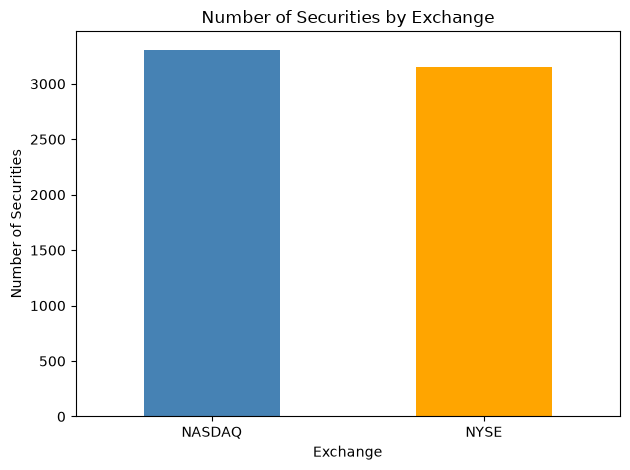

In [9]:
exchange_counts = stocks_clean["exchange"].value_counts()
display(exchange_counts)

exchange_counts.plot(kind="bar", color=["steelblue", "orange"])
plt.title("Number of Securities by Exchange")
plt.xlabel("Exchange")
plt.ylabel("Number of Securities")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Sectors

sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
Name: count, dtype: int64

Securities with missing sector: 1440


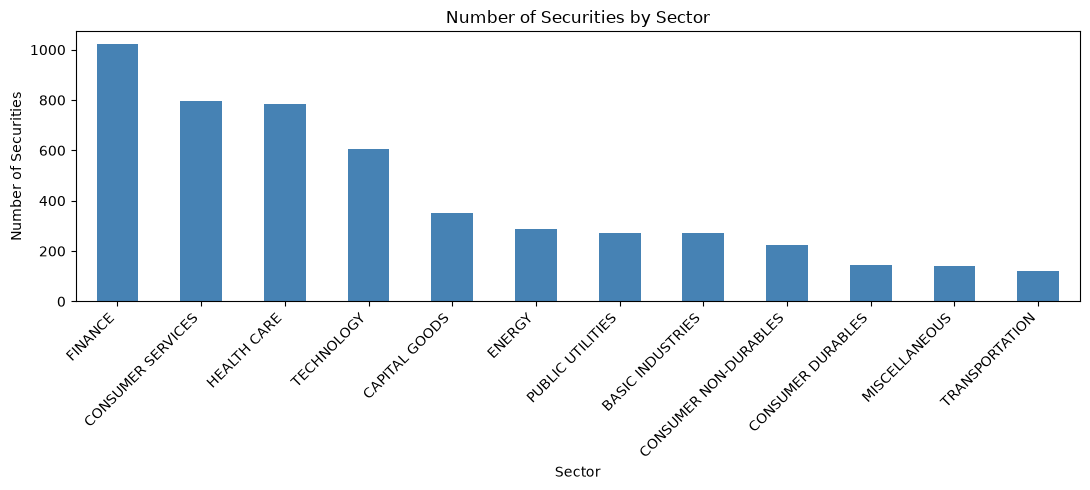

In [10]:
sector_counts = stocks_clean["sector"].value_counts()
display(sector_counts)

print("Securities with missing sector:", stocks_clean["sector"].isna().sum())

sector_counts.plot(kind="bar", figsize=(11, 5), color="steelblue")
plt.title("Number of Securities by Sector")
plt.xlabel("Sector")
plt.ylabel("Number of Securities")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Part 4 Answers


**Stock exchanges**

- The exchanges represented are NASDAQ and NYSE.
- NASDAQ has 3,308 securities; NYSE has 3,151.
- NASDAQ has 157 more securities than NYSE in the cleaned stock dataset.

**Sectors**

- Finance has the most securities (1,022), followed by Consumer Services (796) and Health Care (784).
- 1,440 securities have missing sector information.
- A sector might be missing because the source did not classify that security, or because some types of securities do not fit the available sector labels. Missing information alone is not a reason to delete the record.

## Part 5 — Explore Numerical Data

In [11]:
columns = ["open", "high", "low", "close", "volume"]
summary = prices[columns].describe().T
summary["median"] = prices[columns].median()

display(summary[["mean", "median", "std", "min", "25%", "50%", "75%", "max"]])

,mean,median,std,min,25%,50%,75%,max
open,7.605823e+01,15.45,2.849639e+03,0.0004,7.50,15.45,29.719999,2.034000e+06
high,7.803857e+01,15.66,2.997937e+03,0.0004,7.63,15.66,30.100000,2.070000e+06
low,7.422064e+01,15.24,2.746059e+03,0.0001,7.36,15.24,29.280001,1.440000e+06
close,7.611403e+01,15.45,2.870159e+03,0.0002,7.50,15.45,29.719999,1.779750e+06
volume,1.227043e+06,126000.00,1.316686e+07,1.0000,22100.00,126000.00,607400.000000,4.483504e+09


In [12]:
close_mean = summary.loc["close", "mean"]
close_median = summary.loc["close", "median"]
difference = close_mean - close_median

print(f"1. Mean closing price: {close_mean:,.2f}")
print(f"2. Median closing price: {close_median:,.2f}")
print(f"3. Mean minus median: {difference:,.2f}")
print(f"4. Largest standard deviation: {summary['std'].idxmax()}")
print("\n5. Maximum value of each variable:")
display(summary["max"])

1. Mean closing price: 76.11
2. Median closing price: 15.45
3. Mean minus median: 60.66
4. Largest standard deviation: volume

5. Maximum value of each variable:


open      2.034000e+06
high      2.070000e+06
low       1.440000e+06
close     1.779750e+06
volume    4.483504e+09
Name: max, dtype: float64

### Part 5 Interpretation


The table reports the mean, median, standard deviation, minimum, maximum, and quartiles for `open`, `high`, `low`, `close`, and `volume`.

The difference between the mean and median closing prices helps us assess whether unusually high values may be pulling the mean upward. Very large maximum values are worth investigating in Part 6; they should not be removed without checking the associated records.

## Part 6 — Investigate Unusual Values

### 6.1 Highest Closing Prices

In [13]:
highest_close = prices.nlargest(10, "close")[
    ["ticker", "date", "open", "high", "low", "close", "volume"]
]
display(highest_close)

,ticker,date,open,high,low,close,volume
12146443,SCON,2000-02-28,1395000.000,1797750.0,1368000.00,1779750.0,400
12146459,SCON,2000-02-29,2034000.000,2070000.0,1440000.00,1595250.0,400
12146546,SCON,2000-03-13,900000.000,1404000.0,861750.00,1363500.0,300
17889354,CODA,2001-02-05,1354500.000,1736700.0,1354500.00,1354500.0,34
2444619,TVIX,2013-02-26,1375000.000,1542500.0,1300000.00,1347500.0,100
12146480,SCON,2000-03-02,1120500.000,1368000.0,1098280.75,1261125.0,200
12146437,SCON,2000-02-25,873561.625,1369125.0,873000.00,1215000.0,200
17107201,TOPS,2016-08-01,783000.000,1276200.0,783000.00,1189800.0,100
12146465,SCON,2000-03-01,1368000.000,1512000.0,1107000.00,1134000.0,300
12146562,SCON,2000-03-14,1352250.000,1354500.0,1080000.00,1111500.0,100


### 6.2 Highest Adjusted Closing Prices

In [14]:
highest_adjusted = prices.nlargest(10, "adj_close")[
    ["ticker", "date", "close", "adj_close", "volume"]
]
display(highest_adjusted)

,ticker,date,close,adj_close,volume
6174033,AAN,1987-02-27,1.296296,1.894962e+19,346900
6174039,AAN,1987-03-10,1.296296,1.894962e+19,20200
6174040,AAN,1987-03-11,1.296296,1.894962e+19,18900
6174041,AAN,1987-03-12,1.296296,1.894962e+19,27000
6174044,AAN,1987-03-17,1.296296,1.894962e+19,31000
6174045,AAN,1987-03-18,1.296296,1.894962e+19,272700
6174046,AAN,1987-03-19,1.296296,1.894962e+19,4000
6174049,AAN,1987-03-25,1.296296,1.894962e+19,184900
6174051,AAN,1987-03-27,1.287037,1.881428e+19,205200
6174050,AAN,1987-03-26,1.268519,1.854356e+19,20200


### Part 6 Answers and Cleaning Decision

#### 6.1 Highest Closing Prices

1. **Which securities have the highest closing prices?**  
   SCON has the highest closing price. Other securities among the top ten are CODA, TVIX, and TOPS.

2. **When did these observations occur?**  
   The highest SCON closing price occurred on February 28, 2000. The other top-ten observations occurred between 2000 and 2016.

3. **What was the trading volume?**  
   On February 28, 2000, SCON closed at 1,779,750 with a trading volume of 400. Volumes for the other top-ten records range from 34 to 400.

4. **Do the observations appear unusual?**  
   Yes. The closing prices are extremely high, and the reported trading volumes are low.

5. **Can we conclude that they are errors?**  
   No. The table alone does not establish why these prices are so high. They need further investigation before they can be classified as errors.

#### 6.2 Highest Adjusted Closing Prices

1. **Which ticker has very large adjusted closing values?**  
   All ten highest adjusted closing values belong to AAN.

2. **How do `close` and `adj_close` compare?**  
   For the highest row, `close` is approximately 1.296296, while `adj_close` is approximately 1.894962 × 10¹⁹. This is an exceptionally large difference.

3. **When do the unusual values occur?**  
   The displayed AAN records occurred between February 27 and March 27, 1987.

4. **Do the values appear unusual?**  
   Yes. Adjusted closing values around 10¹⁹ are highly suspicious when the corresponding closing prices are around 1.3. The cause needs investigation.

5. **Should they automatically be deleted?**  
   No. I would first check the source data and adjustment calculation. These values may indicate a data or adjustment problem, but this table alone does not confirm the cause.

#### Cleaning Decision

I kept the unusual records for now and documented them for investigation. I did not change or delete their prices without verifying the cause.

## Part 7 — Visualize the Data

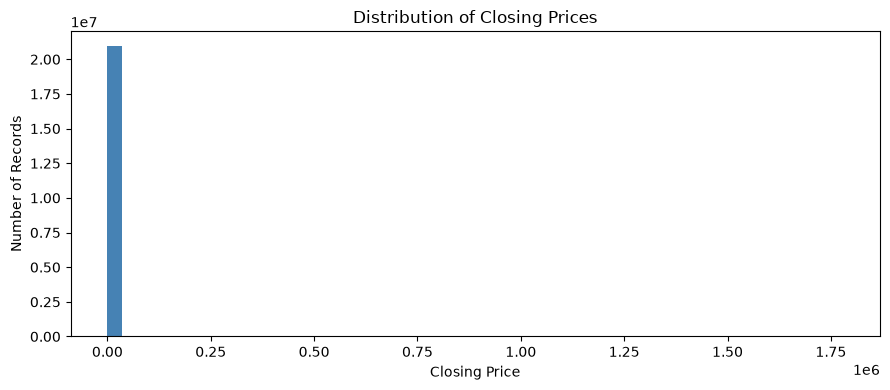

In [15]:
plt.figure(figsize=(9, 4))
plt.hist(prices["close"], bins=50, color="steelblue")
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

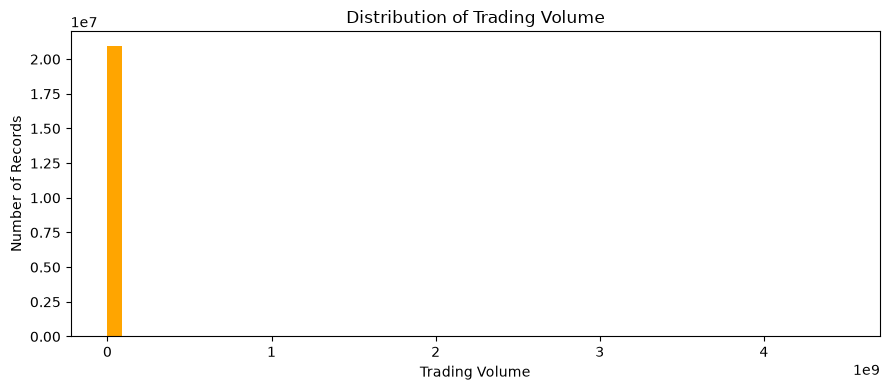

In [16]:
plt.figure(figsize=(9, 4))
plt.hist(prices["volume"], bins=50, color="orange")
plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

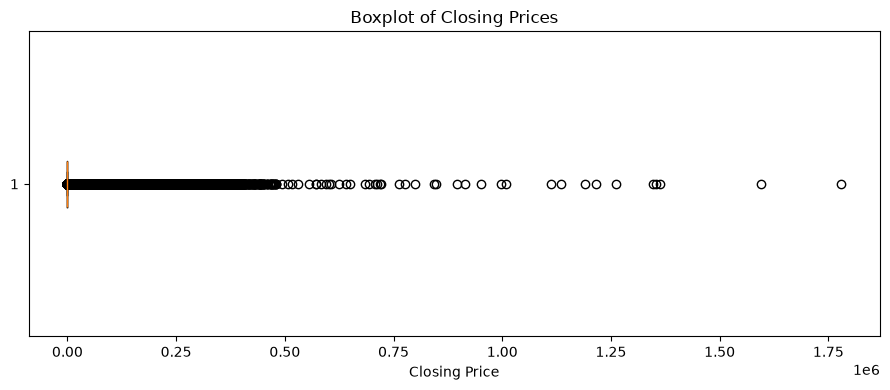

In [17]:
plt.figure(figsize=(9, 4))
plt.boxplot(prices["close"], orientation="horizontal")
plt.title("Boxplot of Closing Prices")
plt.xlabel("Closing Price")
plt.tight_layout()
plt.show()

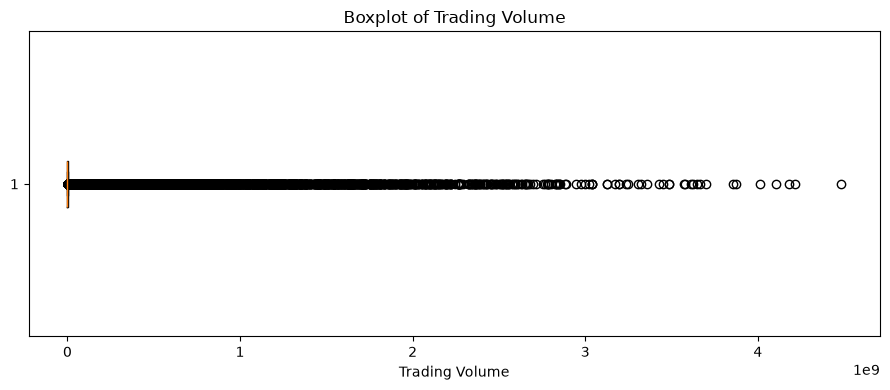

In [18]:
plt.figure(figsize=(9, 4))
plt.boxplot(prices["volume"], orientation="horizontal")
plt.title("Boxplot of Trading Volume")
plt.xlabel("Trading Volume")
plt.tight_layout()
plt.show()

### Part 7 Answers

1. **What does the closing price distribution look like?**  
   Most closing prices are concentrated near the lower end of the range, while a small number are extremely high.

2. **Is it symmetric or skewed?**  
   It is right-skewed, with a long tail toward high closing prices.

3. **Are there extreme values?**  
   Yes. Part 6 identified closing prices above one million.

4. **What does the volume distribution look like?**  
   Most records have relatively low volume compared with the largest values. The distribution has a long right tail.

5. **What do the boxplots show?**  
   They show potential high-value outliers in closing price and trading volume. These observations require investigation before any cleaning decision.

6. **How do the charts compare with Part 5 statistics?**  
   The long right tails help explain why maximum values are much larger than typical values. If the mean exceeds the median in Part 5, that is also consistent with right-skewed data.

## Part 8 — Explore One Stock and Summarize Findings

### AHH Closing Price Over Time

Ticker: AHH
Number of price records: 1336
First date: 2013-05-08
Last date: 2018-08-24
Highest close: 16.10 on 2018-08-21
Lowest close: 8.85 on 2014-02-07
Longest gap between records: 4 days
Gaps longer than 7 days: 0


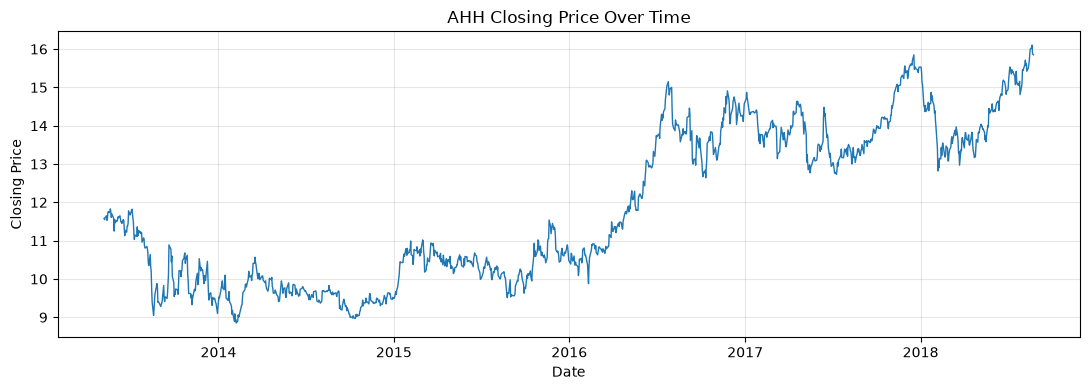

In [19]:
one_stock = prices.loc[prices["ticker"] == "AHH", ["date", "close"]].copy()
one_stock["date"] = pd.to_datetime(one_stock["date"])
one_stock = one_stock.sort_values("date")

print("Ticker: AHH")
print("Number of price records:", len(one_stock))
print("First date:", one_stock["date"].min().date())
print("Last date:", one_stock["date"].max().date())

highest = one_stock.loc[one_stock["close"].idxmax()]
lowest = one_stock.loc[one_stock["close"].idxmin()]

print(f"Highest close: {highest['close']:,.2f} on {highest['date'].date()}")
print(f"Lowest close: {lowest['close']:,.2f} on {lowest['date'].date()}")

date_gaps = one_stock["date"].diff()
print("Longest gap between records:", date_gaps.max().days, "days")
print("Gaps longer than 7 days:", (date_gaps > pd.Timedelta(days=7)).sum())

plt.figure(figsize=(11, 4))
plt.plot(one_stock["date"], one_stock["close"], linewidth=1)
plt.title("AHH Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Part 8 Answers

1. **Which ticker did you choose?**  
   I chose AHH. The dataset contains 1,336 daily price records for this ticker, from May 8, 2013, to August 24, 2018.

2. **How does its price change over time?**  
   AHH's closing price changed over the period. It reached its lowest recorded value in 2014 and its highest near the end of the available data in 2018. These two points show that its price was higher at its 2018 peak than at its 2014 low; they do not imply that it rose continuously.

3. **Are there periods of unusually high or low prices?**  
   The lowest closing price was 8.85 on February 7, 2014. The highest was 16.10 on August 21, 2018. These are the low and high points in AHH's available records.

4. **Are there gaps in the available data?**  
   The longest interval between consecutive records was four days, and there were no intervals longer than seven days. Short intervals without records can reflect weekends or market holidays; this check found no extended gap.

5. **What additional information would you need to explain major price changes?**  
   Earnings reports, company announcements, dividends, stock splits, and broader market conditions would help explain changes in AHH's price.

## Final Summary

### Data
The stock information dataset originally contained 6,460 rows and 5 columns. The full historical price dataset contained 20,973,889 rows and 8 columns. The datasets are linked by `ticker`, with multiple dated price records possible for each security.

### Data Quality and Cleaning
The stock information dataset had 1,440 missing `sector` values and 1,440 missing `industry` values. The price dataset had no missing values, exact duplicate rows, or duplicate `ticker` and `date` combinations. One stock-information row contained column labels as data (`Symbol`), so I removed it from a copy, leaving 6,459 rows. I retained securities with missing classifications because those blanks alone do not establish an error. An OHLC consistency check flagged 2,076 price records for further investigation; I did not automatically delete them.

### Numerical Data
The descriptive statistics showed a wide range of closing prices and trading volumes, including maximum values much larger than typical observations. Closing prices and trading volumes were examined using means, medians, standard deviations, quartiles, and maximum values. Volume counts shares while prices measure price per share, so their standard deviations should not be compared as though they use the same units.

### Unusual Observations
SCON had the highest displayed closing price: 1,779,750 on February 28, 2000, with a trading volume of 400. AAN had adjusted closing values around 1.89 × 10¹⁹ in records from 1987, although the corresponding closing prices were around 1.3. Those adjusted values are highly suspicious and require verification against the source and adjustment method. I retained the unusual price records because their cause has not been confirmed.

### Visualizations
The closing-price and trading-volume charts showed concentrations of observations at the lower end of their ranges and long tails toward very large values. The boxplots highlighted potential high-value outliers. The extreme values compressed much of each full-range chart near the left edge.

### One Stock: AHH
AHH had 1,336 price records from May 8, 2013, through August 24, 2018. Its lowest closing price was 8.85 on February 7, 2014, and its highest was 16.10 on August 21, 2018. The longest interval between consecutive records was four days, with no interval longer than seven days. Company announcements, earnings, corporate actions, and market conditions would help explain its price changes.

### Future Questions

1. Does trading volume increase during periods of large daily closing-price changes?
2. Do securities in different sectors have different levels of price volatility?